In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [2]:
adata = sc.read_h5ad('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_1plex_genotyped_adata.h5ad')
adata.obsm['predicted_genotypes'] = adata.obsm['predicted_genotypes'].replace({0: 'wt', 1: 'mutated', 2: 'heterozygous'}).astype(object).copy()
adata.obsm['genotypes'] = adata.obsm['genotypes'].replace({0: 'wt', 1: 'mutated', 2: 'heterozygous'}).astype(object).copy()


In [3]:
adata = adata[adata.obs['BC'] == 'CL3_HB_Betaine_BC001'].copy()

84 84
15 15
18 18


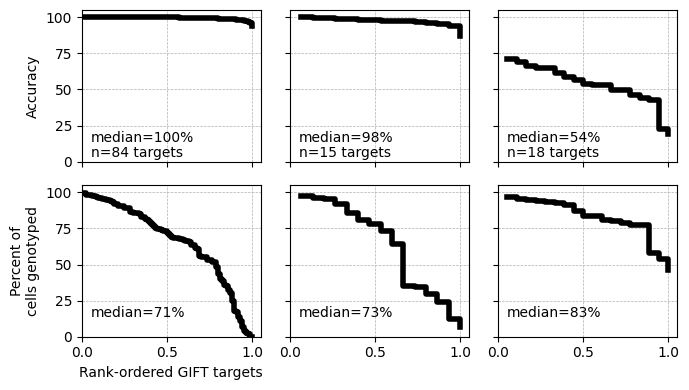

In [ ]:
### compute accuracy and percent genotyped for cells of each predicted genotype

fig, axs = plt.subplots(2, 3, figsize=(7,4), sharex=True, sharey=True)

genotypes = ['wt','mutated','heterozygous']
titles = ['wt cells', 'mutated cells', 'heterozygous cells']

for col, (genotype, title) in enumerate(zip(genotypes, titles)):
    accuracy = ((adata.obsm['genotypes'][adata.obsm['predicted_genotypes'] == genotype] == genotype).sum() / adata.obsm['genotypes'][adata.obsm['predicted_genotypes'] == genotype].notna().sum()).dropna()
    accuracy = accuracy.drop(['HTT c.8157G>A'], errors='ignore')
    if genotype == 'heterozygous':
        accuracy = accuracy.drop(['JAK2 c.1849G>T'], errors='ignore') ## remove JAK2 for heterozygous because SET-2 is both het and homozygous
    if genotype == 'wt':
        accuracy = accuracy.drop(['BCR-ABL'], errors='ignore') ## remove BCR-ABL for wt because it can't be detected

    n_relevant_cells = (adata.obsm['predicted_genotypes'] == genotype).sum()
    n_genotyped = adata.obsm['genotypes'][adata.obsm['predicted_genotypes'] == genotype].notna().sum()
    prop_genotyped = (n_genotyped / n_relevant_cells).dropna()
    prop_genotyped = prop_genotyped.drop(['HTT c.8157G>A'], errors='ignore')
    if genotype == 'heterozygous':
        prop_genotyped = prop_genotyped.drop(['JAK2 c.1849G>T'], errors='ignore') ## remove JAK2 for heterozygous because SET-2 is both het and homozygous
    if genotype == 'wt':
        prop_genotyped = prop_genotyped.drop(['BCR-ABL'], errors='ignore') ## remove BCR-ABL for wt because it can't be detected
    
    # Plot cumulative distributions with no fill and manual normalization
    prop_genotyped_sorted = 100* np.sort(prop_genotyped)[::-1]
    accuracy_sorted = 100* np.sort(accuracy)[::-1]
    n_prop = len(prop_genotyped_sorted)
    n_acc = len(accuracy_sorted)
    axs[1, col].step(np.arange(1, n_prop + 1) / n_prop, prop_genotyped_sorted, where='post', color='k', linewidth=4)
    axs[0, col].step(np.arange(1, n_acc + 1) / n_acc, accuracy_sorted, where='post', color='k', linewidth=4)
    axs[0, col].set_ylim(0, 105)
    axs[1, col].set_ylim(0, 105)
    axs[0, col].set_xlim(0, 1.05)
    axs[1, col].set_xlim(0, 1.05)

    axs[0, col].grid(True, linestyle='--', linewidth=0.5)
    axs[1, col].grid(True, linestyle='--', linewidth=0.5)
    axs[0, col].text(
        0.05, 0.1, f'n={len(accuracy)} targets',
        transform=axs[0, col].transAxes,
        ha='left', va='top', fontsize=10
    )
    axs[0, col].text(
        0.05, 0.2, f'median={(accuracy.median() * 100):.0f}%',
        transform=axs[0, col].transAxes,
        ha='left', va='top', fontsize=10
    )
    axs[1, col].text(
        0.05, 0.2, f'median={(prop_genotyped.median() * 100):.0f}%',
        transform=axs[1, col].transAxes,
        ha='left', va='top', fontsize=10
    )
    print(len(prop_genotyped), len(accuracy))
axs[1, 0].set_xlabel('Rank-ordered GIFT targets')

axs[0, 0].set_ylabel('Accuracy')
axs[1, 0].set_ylabel('Percent of\ncells genotyped')

plt.tight_layout()

plt.savefig('../plots/cell_genotyping_metrics_gapfill_1plex_betaine.pdf', bbox_inches='tight')